In [16]:
import matplotlib.pyplot as plt
import numpy as np

Plotting in 3d sphere using hyperparameters

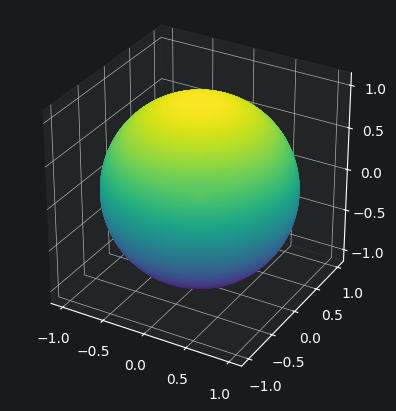

In [17]:
fig = plt.figure()
ax = plt.axes(projection='3d')

points = []

for ds in np.arange(0, 2*np.pi, 0.01):
    for dt in np.arange(0, np.pi, 0.01):
        points.append((
            np.cos(ds) * np.sin(dt),
            np.sin(ds) * np.sin(dt),
            np.cos(dt)
        ))

points = np.array(points)

ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=points[:, 2], cmap='viridis')
ax.set_box_aspect([1, 1, 1])

plt.show()

Reshape matrices

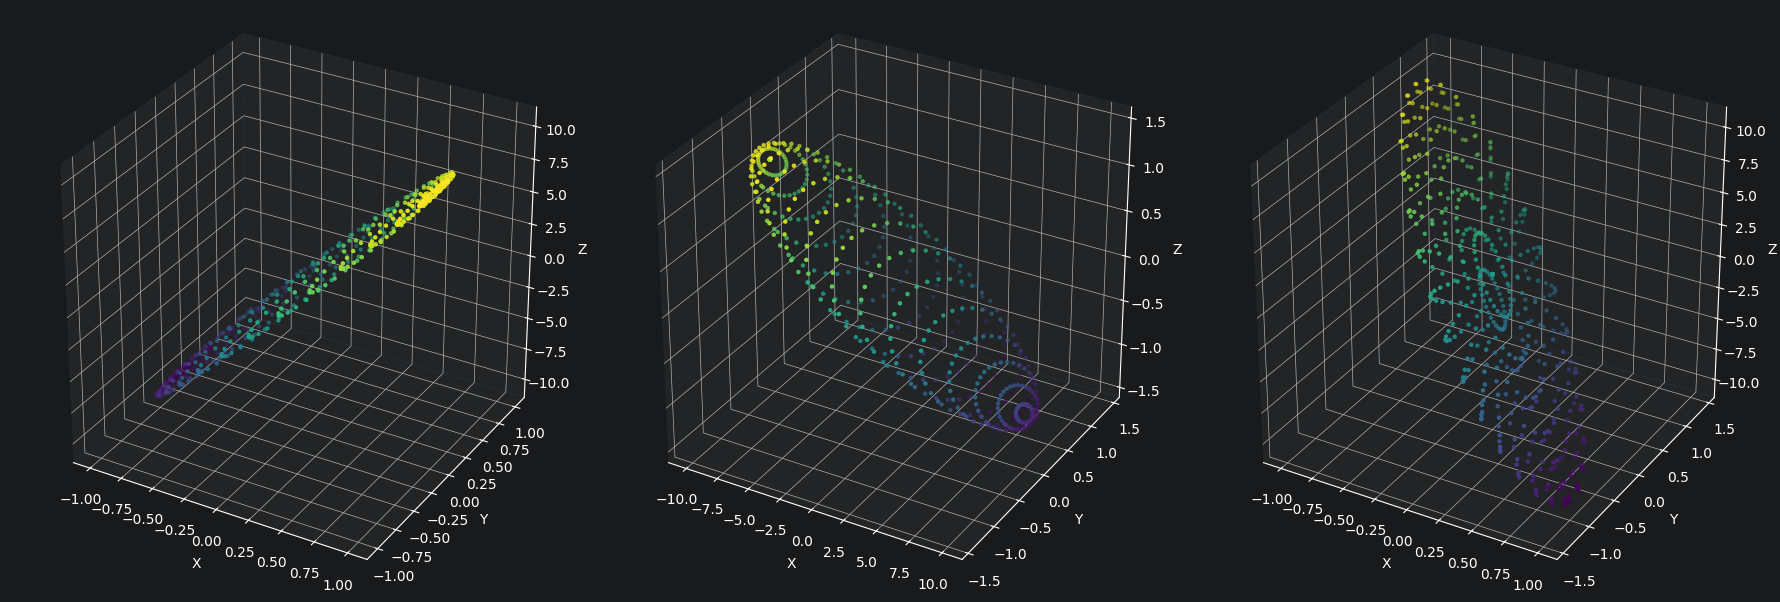

In [43]:
A = np.array([
    [0, 0, 1],
    [0,  1, 0],
    [1,  0, 10]
])
B = np.array([
    [1, -1, -0],
    [0,  1, -1],
    [-10,  0, 1]
])
C = np.array([
    [1, -1, -10],
    [0,  1, -1],
    [0,  0, 1]
])

trans = [A, B, C]

#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')

fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})


for i, (M, ax) in enumerate(zip(trans, axs)):
    output = points @ M

    sc = ax.scatter(output[:, 0], output[:, 1], output[:, 2],
                    c=output[:, 2], cmap='viridis', s=5)

    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()


SVD

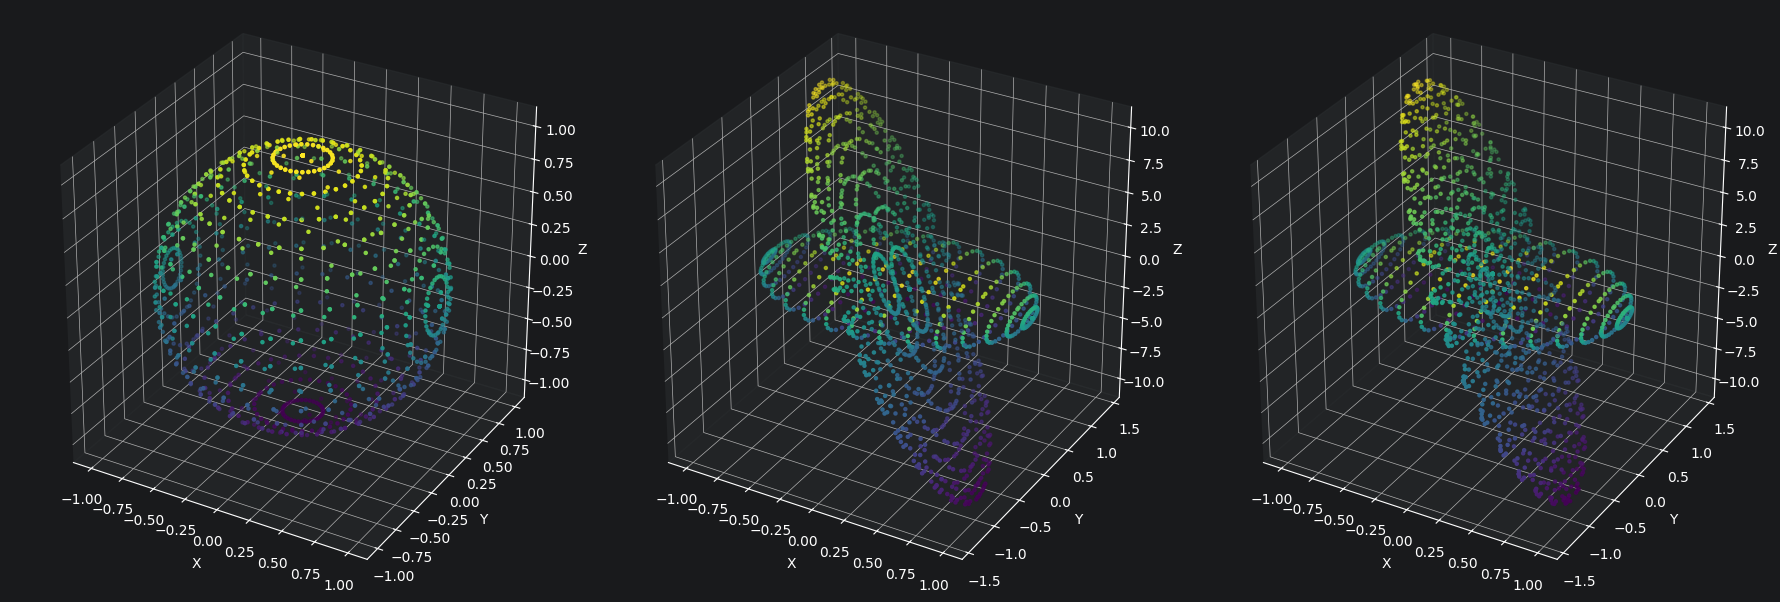

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})

for i, (M, ax) in enumerate(zip(trans, axs)):
    U, Sigma, V = np.linalg.svd(M)

    Sigma_mat = np.diag(Sigma)
    trans = [V, Sigma_mat @ V, U @ Sigma_mat @ V]

    for t in trans:
        output = points @ t
        sc = ax.scatter(output[:, 0], output[:, 1], output[:, 2],
                        c=output[:, 2], cmap='viridis', s=5)

        ax.set_box_aspect([1, 1, 1])
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

plt.tight_layout()
plt.show()